In [56]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")

In [60]:
# ================================
# 2. Load Datasets
# ================================
# Replace with your downloaded file paths
trader_data = pd.read_csv(r"C:\Users\neeth\Downloads\Historical_Data.csv")
sentiment_data = pd.read_csv(r"C:\Users\neeth\Downloads\fear_greed_index.csv")


In [62]:
# ================================
# 3. Inspect Data
# ================================
print(trader_data.head())


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [64]:
print(sentiment_data.head())


    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [66]:
print(trader_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [42]:
print(sentiment_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [74]:
print(trader_data.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [139]:
print(trader_data.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Time', 'date'],
      dtype='object')


In [137]:
print(sentiment_data.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [90]:
trader_data['date'] = pd.to_datetime(trader_data['Timestamp'])
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'])


In [96]:
trader_data['date'] = pd.to_datetime(trader_data['Timestamp'], errors='coerce')
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'], errors='coerce')
print(trader_data['date'].dtype)
print(sentiment_data['date'].dtype)



datetime64[ns]
datetime64[ns]


In [108]:
trader_data['date'] = trader_data['date'].dt.date
sentiment_data['date'] = sentiment_data['date'].dt.date
print(trader_data[['Timestamp', 'date']].head())




      Timestamp        date
0  1.730000e+12  1970-01-01
1  1.730000e+12  1970-01-01
2  1.730000e+12  1970-01-01
3  1.730000e+12  1970-01-01
4  1.730000e+12  1970-01-01


In [121]:
# Convert timestamps properly
trader_data['date'] = pd.to_datetime(trader_data['Timestamp'], unit='ms', errors='coerce')
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'], errors='coerce')

# Extract just the date
trader_data['date'] = trader_data['date'].dt.date
sentiment_data['date'] = sentiment_data['date'].dt.date




In [125]:
def merge_on_date(trader_data, sentiment_data, ts_col='Timestamp', sentiment_col='date'):
    # Ensure timestamp column is integer
    trader_data[ts_col] = trader_data[ts_col].astype('int64')
    
    # Convert both to datetime
    trader_data['date'] = pd.to_datetime(trader_data[ts_col], unit='ms', errors='coerce').dt.date
    sentiment_data['date'] = pd.to_datetime(sentiment_data[sentiment_col], errors='coerce').dt.date
    
    # Merge safely
    merged = pd.merge(trader_data, sentiment_data[['date','classification']], on='date', how='left')
    return merged

# Usage
df = merge_on_date(trader_data, sentiment_data)
print(df.head())


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [145]:

# --- Group analysis ---
avg_pnl = df.groupby('classification')['Closed PnL'].mean()
total_pnl = df.groupby('classification')['Closed PnL'].sum()

In [147]:
print("Average PnL by Sentiment:\n", avg_pnl)
print("Total PnL by Sentiment:\n", total_pnl)

Average PnL by Sentiment:
 classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64
Total PnL by Sentiment:
 classification
Extreme Greed    1.769655e+05
Fear             6.699925e+06
Greed            3.189617e+06
Neutral          1.587424e+05
Name: Closed PnL, dtype: float64


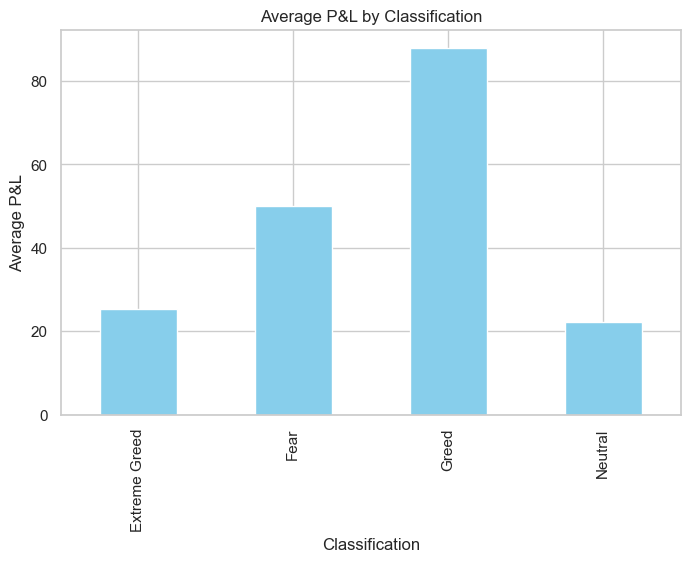

In [162]:

plt.figure(figsize=(8,5))
avg_pnl.plot(kind='bar', color='skyblue')
plt.title('Average P&L by Classification')
plt.xlabel('Classification')
plt.ylabel('Average P&L')
plt.show()


In [170]:
print(df.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Time', 'date', 'classification'],
      dtype='object')


In [ ]:
trader_data = pd.read_csv(r"C:\Users\neeth\Downloads\Historical_Data.csv")
sentiment_data = pd.read_csv(r"C:\Users\neeth\Downloads\fear_greed_index.csv")

In [235]:
trade_data = pd.read_csv(r"C:\Users\neeth\Downloads\Historical_Data.csv")
sentiment_data = pd.read_csv(r"C:\Users\neeth\Downloads\fear_greed_index.csv")

In [ ]:
trade_data['timestamp'] = pd.to_datetime(trade_data['timestamp'], errors='coerce')
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'], errors='coerce')
merged_data = pd.merge(trade_data, sentiment_data, left_on='timestamp', right_on='date', how='left')
merged_data['classification'] = merged_data['classification'].fillna('neutral')
# Example: simple diff of execution price
merged_data['PL'] = merged_data['Execution Price'].diff()


avg_pnl_by_sentiment = merged_data.groupby('classification')['PL'].mean()

# Plotting
plt.figure(figsize=(8,6))
avg_pnl_by_sentiment.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average PnL by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average PnL')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()